# Imports & HelperFuncs

In [6]:
from testFuncs import load_dataset_df
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
base_path = base_img_path = "../memoriaLatex"

In [7]:
from pathlib import Path
from functools import lru_cache

@lru_cache
def n_instances(ds, dataset_root=Path("dataset")):
    return load_dataset_df(
        dataset=ds,
        noise_type="data_base",
        split="cc",
        encoding=None,
        root=dataset_root,
    ).shape[0]

def get_available_datasets(dataset_root=Path("dataset"), n=None, reverse=False):
    base_dir = dataset_root / "data_base"
    datasets = sorted(
        [p.name for p in base_dir.iterdir() if p.is_dir()],
        key=lambda ds: (n_instances(ds, dataset_root), ds),
        reverse=reverse,
    )
    return datasets if n is None else datasets[:n]
    
keel_datasets = get_available_datasets(Path("dataset"), n=30)
print(keel_datasets)

['zoo', 'hayes-roth', 'lymphography', 'iris', 'autos', 'wine', 'sonar', 'glass', 'newthyroid', 'heart', 'cleveland', 'splice', 'ecoli', 'ionosphere', 'dermatology', 'monk-2', 'led7digit', 'wdbc', 'balance', 'pima', 'vehicle', 'vowel', 'german', 'flare', 'nursery', 'contraceptive', 'yeast', 'car', 'shuttle', 'segment']


# Simulations

In [ ]:
import numpy as np

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import balanced_accuracy_score
from tqdm.auto import tqdm
import pickle

from filters import *
from filters.noiseScoreFiltering import NoiseScoreFilter


clf = LogisticRegression()

# Fixed dataset loading config.
fixed_dataset_info = {
    "noise_type": "cla_rand",
    "encoding": "onehot",
}


base_estimators = [
    ("DT", DecisionTreeClassifier(
        criterion="entropy",
        splitter="best",
        random_state=33
    )),

    ("KNN3", KNeighborsClassifier(
        n_neighbors=3
    )),

    ("LR", LogisticRegression(
        max_iter=1000,
        random_state=33
    )),

    ("GNB", GaussianNB()),

    ("DT_SMALL", DecisionTreeClassifier(
        criterion="gini",
        splitter="best",
        max_depth=5,
        min_samples_leaf=2,
        random_state=33
    )),

    ("SGD_LOG", SGDClassifier(
        loss="log_loss",
        max_iter=1000,
        tol=1e-3,
        random_state=33
    )),
]

# Base filters that expose noise_score_.
base_filters = {
    "ENN": ENNFilter(n_neighbors=9, action="detect"),
    "ENNProb": ENNProbFilter(n_neighbors=9, action="detect"),
    "NCNEdit": NCNEdit(n_neighbors=9, action="detect"),
    "EF" : EnsembleFiltering(
                estimators=[est for _, est in base_estimators],
                cv=10,
                mode="threshold",
                threshold = 0.8,
                action="remove",
                random_state=33,
            )
}

# Noise-score-based filters.
noiseScore_filters = {
    "NSFilter_mean_": NoiseScoreFilter(threshold="mean"),
    "NSFilter_adaptative": NoiseScoreFilter(threshold="adaptative"),
    "NSFilter_rat_valley": NoiseScoreFilter(threshold="rational_valley"),
    "NSFilter_th_0.3": NoiseScoreFilter(threshold=0.3),
    "NSFilter_th_0.5": NoiseScoreFilter(threshold=0.5),
    "NSFilter_th_0.7": NoiseScoreFilter(threshold=0.7),
    "NSFilter_quant_0.5": NoiseScoreFilter(threshold="quantile", quantile=0.5),
    "NSFilter_quant_0.75": NoiseScoreFilter(threshold="quantile", quantile=0.7),
    "NSFilter_quant_0.95": NoiseScoreFilter(threshold="quantile", quantile=0.99),
}

def make_sample_weights(noise_scores, kind="linear", alpha=1.0):
    scores = np.asarray(noise_scores, dtype=float)
    scores = np.clip(scores, 0.0, 1.0)

    if kind == "linear":
        weights = 1.0 - scores
    elif kind == "exp":
        weights = np.exp(-alpha * scores)
    else:
        raise ValueError("kind must be 'linear' or 'exp'")

    weights = np.clip(weights, 1e-3, None)
    weights = weights / weights.mean()
    return weights

results = {
    "dataset_id": [],
    "fold_id": [],
    "seed": [],
    "filter_id": [],
    "noise_k": [],
    "bal_acc": [],
}
seeds = [1,2,3,4,5]
for noise_k in [5, 25, 50]:
    for seed_k in seeds:
        for ds_idx, dataset in enumerate(tqdm(keel_datasets[:30])):
            print(f"noise:{noise_k}%, (ds_idx:{ds_idx},{dataset}), seed:{seed_k}")
            for base_filter_name, base_filter in base_filters.items():
                for fold_idx in range(1, 6):
                    train_fold_ds = load_dataset_df(
                        dataset=dataset,
                        split="tra",
                        fold=fold_idx,
                        k=noise_k,
                        seed=seed_k,
                        **fixed_dataset_info,
                    )
                    test_fold_ds = load_dataset_df(
                        dataset=dataset,
                        split="tst",
                        fold=fold_idx,
                        k=noise_k,
                        seed=seed_k,
                        **fixed_dataset_info,
                    )

                    X_tr = train_fold_ds.iloc[:, :-1]
                    y_tr = train_fold_ds.iloc[:, -1]
                    X_ts = test_fold_ds.iloc[:, :-1]
                    y_ts = test_fold_ds.iloc[:, -1]

                    X_tr_np = X_tr.to_numpy()
                    X_ts_np = X_ts.to_numpy()
                    y_tr_np = y_tr.to_numpy() if hasattr(y_tr, "to_numpy") else np.asarray(y_tr)
                    y_ts_np = y_ts.to_numpy() if hasattr(y_ts, "to_numpy") else np.asarray(y_ts)

                    # Scale before filtering.
                    sc = StandardScaler()
                    X_tr_sc = sc.fit_transform(X_tr_np)
                    X_ts_sc = sc.transform(X_ts_np)

                    # 1) Baseline without filtering.
                    model = clone(clf)
                    model.fit(X_tr_sc, y_tr_np)

                    results["dataset_id"].append(dataset)
                    results["fold_id"].append(fold_idx)
                    results["seed"].append(seed_k)
                    results["filter_id"].append("None")
                    results["noise_k"].append(noise_k)
                    results["bal_acc"].append(
                        balanced_accuracy_score(y_ts_np, model.predict(X_ts_sc))
                    )

                    # 2) Fit the base filter on scaled data and train only on kept samples.
                    fitted_base_filter = clone(base_filter)
                    fitted_base_filter.fit(X_tr_sc, y_tr_np)
                    keep_mask = fitted_base_filter.result_.keep_mask

                    X_tr_kept = X_tr_sc[keep_mask]
                    y_tr_kept = y_tr_np[keep_mask]

                    if np.unique(y_tr_kept).size < 2:
                        results["dataset_id"].append(dataset)
                        results["fold_id"].append(fold_idx)
                        results["seed"].append(seed_k)
                        results["filter_id"].append(base_filter_name)
                        results["noise_k"].append(noise_k)
                        results["bal_acc"].append(np.nan)
                    else:
                        model = clone(clf)
                        model.fit(X_tr_kept, y_tr_kept)

                        results["dataset_id"].append(dataset)
                        results["fold_id"].append(fold_idx)
                        results["seed"].append(seed_k)
                        results["filter_id"].append(base_filter_name)
                        results["noise_k"].append(noise_k)
                        results["bal_acc"].append(
                            balanced_accuracy_score(y_ts_np, model.predict(X_ts_sc))
                        )

                    # 3) Weighted training on scaled data.
                    weights_linear = make_sample_weights(
                        fitted_base_filter.noise_score_,
                        kind="linear",
                    )

                    model = clone(clf)
                    model.fit(X_tr_sc, y_tr_np, sample_weight=weights_linear)

                    results["dataset_id"].append(dataset)
                    results["fold_id"].append(fold_idx)
                    results["seed"].append(seed_k)
                    results["filter_id"].append(f"{base_filter_name}_weight_linear")
                    results["noise_k"].append(noise_k)
                    results["bal_acc"].append(
                        balanced_accuracy_score(y_ts_np, model.predict(X_ts_sc))
                    )

                    weights_exp = make_sample_weights(
                        fitted_base_filter.noise_score_,
                        kind="exp",
                        alpha=1.0,
                    )

                    model = clone(clf)
                    model.fit(X_tr_sc, y_tr_np, sample_weight=weights_exp)

                    results["dataset_id"].append(dataset)
                    results["fold_id"].append(fold_idx)
                    results["seed"].append(seed_k)
                    results["filter_id"].append(f"{base_filter_name}_weight_exp")
                    results["noise_k"].append(noise_k)
                    results["bal_acc"].append(
                        balanced_accuracy_score(y_ts_np, model.predict(X_ts_sc))
                    )

                    # 4) Noise-score filters on scaled data.
                    for nsf_name, nsf in noiseScore_filters.items():
                        fitted_nsf = nsf
                        fitted_nsf.noise_scores = fitted_base_filter.noise_score_
                        X_tr_f, y_tr_f = fitted_nsf.fit_resample(X_tr_sc, y_tr_np)

                        if np.unique(y_tr_f).size < 2:
                            results["dataset_id"].append(dataset)
                            results["fold_id"].append(fold_idx)
                            results["seed"].append(seed_k)
                            results["filter_id"].append(f"{base_filter_name}_{nsf_name}")
                            results["noise_k"].append(noise_k)
                            results["bal_acc"].append(np.nan)
                            continue

                        model = clone(clf)
                        model.fit(X_tr_f, y_tr_f)

                        results["dataset_id"].append(dataset)
                        results["fold_id"].append(fold_idx)
                        results["seed"].append(seed_k)
                        results["filter_id"].append(f"{base_filter_name}_{nsf_name}")
                        results["noise_k"].append(noise_k)
                        results["bal_acc"].append(
                            balanced_accuracy_score(y_ts_np, model.predict(X_ts_sc))
                        )
            pickle.dump(results, open(f"./results/nsBased.pkl", "wb"))

  0%|          | 0/30 [00:00<?, ?it/s]

noise:5%, (ds_idx:0,zoo), seed:1


/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated 

noise:5%, (ds_idx:1,hayes-roth), seed:1
noise:5%, (ds_idx:2,lymphography), seed:1


/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated 

...

noise:50%, (ds_idx:13,ionosphere), seed:5
noise:50%, (ds_idx:14,dermatology), seed:5
noise:50%, (ds_idx:15,monk-2), seed:5
noise:50%, (ds_idx:16,led7digit), seed:5
noise:50%, (ds_idx:17,wdbc), seed:5
noise:50%, (ds_idx:18,balance), seed:5
noise:50%, (ds_idx:19,pima), seed:5
noise:50%, (ds_idx:20,vehicle), seed:5
noise:50%, (ds_idx:21,vowel), seed:5
noise:50%, (ds_idx:22,german), seed:5
noise:50%, (ds_idx:23,flare), seed:5
noise:50%, (ds_idx:24,nursery), seed:5


/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in

noise:50%, (ds_idx:25,contraceptive), seed:5
noise:50%, (ds_idx:26,yeast), seed:5
noise:50%, (ds_idx:27,car), seed:5
noise:50%, (ds_idx:28,shuttle), seed:5


/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in

noise:50%, (ds_idx:29,segment), seed:5


In [8]:
import pickle
noise_ks = [5,25,50]
seed_ks = [1,2,3,4,5]
results = pickle.load(open(f"./results/nsBased.pkl", "rb"))
results = pd.DataFrame(results)

In [8]:
from scipy.stats import wilcoxon

import pickle
noise_ks = [5,25,50]
seed_ks = [1,2,3,4,5]
results = pickle.load(open(f"./results/nsBased.pkl", "rb"))
results = pd.DataFrame(results)
# Agrego por 5CV (agrego sobre los folds)
res = results.\
    groupby(["dataset_id", "seed", "filter_id", "noise_k"]).\
        mean().\
    reset_index().\
    drop("fold_id", axis=1)

# Extraigo BalAcc_baseline para cada dataset,seed,noise_k
baseline_res = (
    res[res["filter_id"] == "None"]
    .drop(columns=["filter_id"])
    .rename(columns={"bal_acc": "baseline_bal_acc"})
)
# Añado a cada fila el BalAcc_baseline
res = res.merge(
    baseline_res,
    on=["dataset_id", "seed", "noise_k"],
    how="left",
)

res["bal_acc_diff"] = (res["bal_acc"] - res["baseline_bal_acc"]) * 100
res["base_filter"] = res["filter_id"].str.split("_").str[0]


# Agrego por cada semilla
res = res.\
    groupby(["dataset_id","filter_id", "noise_k", "base_filter"]).\
        mean().\
    reset_index().\
    drop("seed", axis=1)

# Agrego sobre todos los datasets
out = res.\
    drop("dataset_id", axis=1).\
    groupby(["filter_id", "noise_k", "base_filter"]).\
        mean().\
    reset_index()

tests = []

for (noise_k, filter_id), g in res[res["filter_id"] != "None"].groupby(["noise_k", "filter_id"]):
    base_filter = g["base_filter"].iloc[0]

    base = res[
        (res["noise_k"] == noise_k) &
        (res["filter_id"] == base_filter)
    ][["dataset_id", "bal_acc"]].rename(columns={"bal_acc": "base_bal_acc"})

    ext = g[["dataset_id", "bal_acc"]].rename(columns={"bal_acc": "ext_bal_acc"})

    aligned = base.merge(ext, on="dataset_id", how="inner").dropna()
    if len(aligned) == 0:
        continue

    stat, p = wilcoxon(
        aligned["ext_bal_acc"]-aligned["base_bal_acc"],
        alternative="greater",
    )

    tests.append({
        "noise_k": noise_k,
        "filter_id": filter_id,
        "p_value": p,
        "wilcoxon_stat": stat,
        "n": len(aligned),
    })

tests_df = pd.DataFrame(tests)

out = out.merge(
    tests_df[["noise_k", "filter_id", "p_value", "wilcoxon_stat", "n"]],
    on=["noise_k", "filter_id"],
    how="left",
)

out["base_filter"] = out["filter_id"].str.split("_").str[0]

tabla = (
    out.pivot_table(
        index=["base_filter", "filter_id"],
        columns="noise_k",
        values=["bal_acc_diff", "p_value"],
    )
)

tablas = {}
for bf, g in out.groupby("base_filter"):
    orden = (
        g.groupby("filter_id")["bal_acc_diff"]
         .mean()
         .sort_values(ascending=False)
         .index
    )
    tabla = g.pivot_table(
        index="filter_id",
        columns="noise_k",
        values=["bal_acc_diff", "p_value"],
    ).loc[orden]
    tablas[bf] = tabla

for bf, tabla in tablas.items():
    print(f"\n=== {bf} ===")
    display(tabla)

/home/juamp/.pyenv/versions/3.12.10/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/juamp/.pyenv/versions/3.12.10/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/juamp/.pyenv/versions/3.12.10/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/juamp/.pyenv/versions/3.12.10/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/juamp/.pyenv/versions/3.12.10/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/juamp/.pyenv/versions/3.12.10/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWar


=== EF ===


/home/juamp/.pyenv/versions/3.12.10/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


bal_acc_diff                       p_value            \
noise_k                          5         25        50        5         25   
filter_id                                                                     
EF_NSFilter_th_0.5         0.412633  3.271559  4.545428  0.788168  0.159198   
EF_NSFilter_th_0.7         1.137938  3.620230  3.200002  0.043238  0.383604   
EF                         0.606341  3.167958  3.954279       NaN       NaN   
EF_weight_linear           0.832626  2.914698  2.487804  0.202247  0.767727   
EF_NSFilter_rat_valley    -1.483251  2.564790  4.224211  0.999434  0.914701   
EF_NSFilter_th_0.3        -0.651268  2.196247  3.485968  0.997984  0.982732   
EF_NSFilter_mean_         -2.013401  2.163946  4.660496  0.999770  0.986886   
EF_NSFilter_quant_0.75    -2.435692  2.477297  3.475904  0.999906  0.889677   
EF_NSFilter_adaptative    -2.255947  1.772839  3.336946  0.999978  0.999384   
EF_weight_exp              0.415031  0.997130  0.995218  0.715071  0.990170   
EF_NSFilter_quant_0.95     0.040583 -0.086030  0.011078  0.820061  0.999384   
EF_NSFilter_quant_0.5     -5.073386  0.308807  4.275650  0.999999  0.999924   

                                  
noise_k                       50  
filter_id                         
EF_NSFilter_th_0.5      0.002691  
EF_NSFilter_th_0.7      0.956031  
EF                           NaN  
EF_weight_linear        0.840802  
EF_NSFilter_rat_valley  0.213977  
EF_NSFilter_th_0.3      0.845740  
EF_NSFilter_mean_       0.021326  
EF_NSFilter_quant_0.75  0.547334  
EF_NSFilter_adaptative  0.809101  
EF_weight_exp           0.991784  
EF_NSFilter_quant_0.95  0.998506  
EF_NSFilter_quant_0.5   0.291879


=== ENN ===


...

bal_acc_diff                       p_value  \
noise_k                               5         25        50        5    
filter_id                                                                
ENNProb_NSFilter_th_0.5        -0.789112  2.893381  3.601455  0.000031   
ENNProb_NSFilter_th_0.7         0.835303  2.841066  1.015695  0.000616   
ENNProb_weight_linear           0.457607  1.787698  1.325305  0.000792   
ENNProb                        -2.460051  1.087418  3.216271       NaN   
ENNProb_weight_exp              0.176639  0.693598  0.522234  0.007730   
ENNProb_NSFilter_quant_0.95     0.295434  0.159962  0.118905  0.009265   
ENNProb_NSFilter_quant_0.75    -4.768848  1.728480  3.163034  0.973868   
ENNProb_NSFilter_rat_valley    -4.723624  1.070772  3.448215  0.999330   
ENNProb_NSFilter_mean_         -5.720369  0.083257  3.681552  0.999998   
ENNProb_NSFilter_th_0.3        -3.843093 -0.512610  1.041743  0.998183   
ENNProb_NSFilter_quant_0.5     -9.414035 -2.362020  3.210465  1.000000   
ENNProb_NSFilter_adaptative    -8.226057 -2.256547  0.757984  1.000000   

                                                 
noise_k                            25        50  
filter_id                                        
ENNProb_NSFilter_th_0.5      0.000304  0.202247  
ENNProb_NSFilter_th_0.7      0.030283  0.850578  
ENNProb_weight_linear        0.154260  0.701096  
ENNProb                           NaN       NaN  
ENNProb_weight_exp           0.475763  0.845740  
ENNProb_NSFilter_quant_0.95  0.603920  0.900962  
ENNProb_NSFilter_quant_0.75  0.196525  0.327719  
ENNProb_NSFilter_rat_valley  0.664910  0.403915  
ENNProb_NSFilter_mean_       0.990735  0.140043  
ENNProb_NSFilter_th_0.3      0.999998  0.999987  
ENNProb_NSFilter_quant_0.5   0.999983  0.335090  
ENNProb_NSFilter_adaptative  0.999985  0.998262


=== NCNEdit ===


bal_acc_diff                       p_value  \
noise_k                               5         25        50        5    
filter_id                                                                
NCNEdit_NSFilter_th_0.5        -0.742001  2.931382  3.912085  0.000044   
NCNEdit_NSFilter_th_0.7         1.082502  2.579464  1.254135  0.000028   
NCNEdit_weight_linear           0.354049  1.881658  1.467893  0.000007   
NCNEdit_NSFilter_quant_0.75    -4.161117  2.356043  3.320969  0.738226   
NCNEdit_weight_exp              0.009271  0.743850  0.707712  0.000156   
NCNEdit                        -3.216825  0.692837  2.922727       NaN   
NCNEdit_NSFilter_quant_0.95     0.238250  0.103211  0.005863  0.000729   
NCNEdit_NSFilter_rat_valley    -4.766493  0.632866  3.811008  0.963378   
NCNEdit_NSFilter_mean_         -6.328821  0.328586  3.939513  0.998128   
NCNEdit_NSFilter_quant_0.5     -7.902627 -1.039252  4.096185  0.999915   
NCNEdit_NSFilter_adaptative    -7.933639 -0.894733  3.970804  0.999906   
NCNEdit_NSFilter_th_0.3        -4.894822 -1.041317  0.353596  0.994435   

                                                 
noise_k                            25        50  
filter_id                                        
NCNEdit_NSFilter_th_0.5      0.000399  0.102705  
NCNEdit_NSFilter_th_0.7      0.023630  0.830629  
NCNEdit_weight_linear        0.118326  0.642434  
NCNEdit_NSFilter_quant_0.75  0.002917  0.202247  
NCNEdit_weight_exp           0.372827  0.820061  
NCNEdit                           NaN       NaN  
NCNEdit_NSFilter_quant_0.95  0.556403  0.940462  
NCNEdit_NSFilter_rat_valley  0.540352  0.012086  
NCNEdit_NSFilter_mean_       0.830629  0.000978  
NCNEdit_NSFilter_quant_0.5   0.977546  0.001754  
NCNEdit_NSFilter_adaptative  0.968222  0.002463  
NCNEdit_NSFilter_th_0.3      0.999490  0.999737


=== None ===


bal_acc_diff          
noise_k             5    25   50
filter_id                       
None               0.0  0.0  0.0

In [9]:
from scipy.stats import wilcoxon

res = (
    pd.DataFrame(results)
    .groupby(["dataset_id", "filter_id", "noise_k"])
    .mean(numeric_only=True)
    .drop("fold_id", axis=1, errors="ignore")
    .reset_index()
)

baseline_res = (
    res[res["filter_id"] == "None"]
    .drop(columns=["filter_id"])
    .rename(columns={"bal_acc": "baseline_bal_acc"})
)

res = res.merge(
    baseline_res[["dataset_id", "noise_k", "baseline_bal_acc"]],
    on=["dataset_id", "noise_k"],
    how="left",
)

res["bal_acc_diff"] = (res["bal_acc"] - res["baseline_bal_acc"]) * 100
res["base_filter"] = res["filter_id"].str.split("_").str[0]

out = (
    res[res["filter_id"] != "None"]
    .groupby(["noise_k", "filter_id"], as_index=False)["bal_acc_diff"]
    .mean()
    .sort_values(["noise_k", "bal_acc_diff"], ascending=[True, False])
)

tests = []

for (noise_k, filter_id), g in res[res["filter_id"] != "None"].groupby(["noise_k", "filter_id"]):
    base_filter = g["base_filter"].iloc[0]

    base = res[
        (res["noise_k"] == noise_k) &
        (res["filter_id"] == base_filter)
    ][["dataset_id", "bal_acc"]].rename(columns={"bal_acc": "base_bal_acc"})

    ext = g[["dataset_id", "bal_acc"]].rename(columns={"bal_acc": "ext_bal_acc"})

    aligned = base.merge(ext, on="dataset_id", how="inner").dropna()
    if len(aligned) == 0:
        continue

    stat, p = wilcoxon(
        aligned["ext_bal_acc"]-aligned["base_bal_acc"],
        alternative="greater",
    )

    tests.append({
        "noise_k": noise_k,
        "filter_id": filter_id,
        "p_value": p,
        "wilcoxon_stat": stat,
        "n": len(aligned),
    })

tests_df = pd.DataFrame(tests)

out = out.merge(
    tests_df[["noise_k", "filter_id", "p_value", "wilcoxon_stat", "n"]],
    on=["noise_k", "filter_id"],
    how="left",
)

out["base_filter"] = out["filter_id"].str.split("_").str[0]

tabla = (
    out.pivot_table(
        index=["base_filter", "filter_id"],
        columns="noise_k",
        values=["bal_acc_diff", "p_value"],
    )
)

tablas = {}
for bf, g in out.groupby("base_filter"):
    orden = (
        g.groupby("filter_id")["bal_acc_diff"]
         .mean()
         .sort_values(ascending=False)
         .index
    )
    tabla = g.pivot_table(
        index="filter_id",
        columns="noise_k",
        values=["bal_acc_diff", "p_value"],
    ).loc[orden]
    tablas[bf] = tabla

for bf, tabla in tablas.items():
    print(f"\n=== {bf} ===")
    display(tabla)

/home/juamp/.pyenv/versions/3.12.10/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/juamp/.pyenv/versions/3.12.10/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/juamp/.pyenv/versions/3.12.10/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/juamp/.pyenv/versions/3.12.10/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/juamp/.pyenv/versions/3.12.10/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/juamp/.pyenv/versions/3.12.10/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWar


=== EF ===


/home/juamp/.pyenv/versions/3.12.10/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


bal_acc_diff                       p_value            \
noise_k                          5         25        50        5         25   
filter_id                                                                     
EF_NSFilter_th_0.5         0.412633  3.271559  4.545428  0.785016  0.159198   
EF_NSFilter_th_0.7         1.137938  3.620230  3.200002  0.043238  0.383604   
EF                         0.606341  3.167958  3.954279       NaN       NaN   
EF_weight_linear           0.832626  2.914698  2.487804  0.196525  0.767365   
EF_NSFilter_rat_valley    -1.483251  2.564790  4.224211  0.999434  0.914701   
EF_NSFilter_th_0.3        -0.651268  2.196247  3.485968  0.997831  0.982732   
EF_NSFilter_mean_         -2.013401  2.163946  4.660496  0.999770  0.986886   
EF_NSFilter_quant_0.75    -2.435692  2.477297  3.475904  0.999906  0.889677   
EF_NSFilter_adaptative    -2.255368  1.772839  3.335715  0.999978  0.999384   
EF_weight_exp              0.415031  0.997130  0.995218  0.715071  0.990170   
EF_NSFilter_quant_0.95     0.040583 -0.086030  0.011078  0.820061  0.999384   
EF_NSFilter_quant_0.5     -5.073386  0.308807  4.275650  0.999999  0.999924   

                                  
noise_k                       50  
filter_id                         
EF_NSFilter_th_0.5      0.002691  
EF_NSFilter_th_0.7      0.957967  
EF                           NaN  
EF_weight_linear        0.840802  
EF_NSFilter_rat_valley  0.213977  
EF_NSFilter_th_0.3      0.845740  
EF_NSFilter_mean_       0.021326  
EF_NSFilter_quant_0.75  0.547334  
EF_NSFilter_adaptative  0.809101  
EF_weight_exp           0.991784  
EF_NSFilter_quant_0.95  0.998506  
EF_NSFilter_quant_0.5   0.291879


=== ENN ===


bal_acc_diff                       p_value            \
noise_k                           5         25        50        5         25   
filter_id                                                                      
ENN_NSFilter_th_0.7         0.814611  2.804481  1.296343  0.000050  0.001094   
ENN_NSFilter_th_0.5        -1.442086  2.244472  3.770781  0.000012  0.000022   
ENN_weight_linear           0.085451  1.727308  1.415885  0.000094  0.009830   
ENN_weight_exp              0.006152  0.672471  0.618349  0.000190  0.144683   
ENN_NSFilter_quant_0.95     0.210239  0.178340 -0.022747  0.000399  0.264553   
ENN_NSFilter_rat_valley    -4.796933  0.548591  3.524337  0.868939  0.144683   
ENN_NSFilter_quant_0.75    -5.268186  1.564972  2.701702  0.745215  0.004038   
ENN                        -4.180716 -0.135141  2.314823       NaN       NaN   
ENN_NSFilter_mean_         -7.155086 -0.636840  3.784714  0.998720  0.859957   
ENN_NSFilter_th_0.3        -5.509175 -1.897648  0.140787  0.999490  0.999897   
ENN_NSFilter_adaptative    -8.996832 -2.623016  3.620421  0.999723  0.989575   
ENN_NSFilter_quant_0.5     -9.191223 -2.665239  3.662945  0.999791  0.984508   

                                   
noise_k                        50  
filter_id                          
ENN_NSFilter_th_0.7      0.516163  
ENN_NSFilter_th_0.5      0.033332  
ENN_weight_linear        0.350016  
ENN_weight_exp           0.548387  
ENN_NSFilter_quant_0.95  0.735447  
ENN_NSFilter_rat_valley  0.025095  
ENN_NSFilter_quant_0.75  0.219983  
ENN                           NaN  
ENN_NSFilter_mean_       0.003687  
ENN_NSFilter_th_0.3      0.999432  
ENN_NSFilter_adaptative  0.006234  
ENN_NSFilter_quant_0.5   0.004413


=== ENNProb ===


bal_acc_diff                       p_value  \
noise_k                               5         25        50        5    
filter_id                                                                
ENNProb_NSFilter_th_0.5        -0.789112  2.893381  3.601455  0.000031   
ENNProb_NSFilter_th_0.7         0.835303  2.841066  1.015695  0.000616   
ENNProb_weight_linear           0.457607  1.787698  1.325305  0.000792   
ENNProb                        -2.460051  1.087418  3.216271       NaN   
ENNProb_weight_exp              0.176639  0.693598  0.522234  0.007730   
ENNProb_NSFilter_quant_0.95     0.295434  0.159962  0.118905  0.009265   
ENNProb_NSFilter_quant_0.75    -4.768848  1.728480  3.163034  0.973868   
ENNProb_NSFilter_rat_valley    -4.723624  1.070772  3.448215  0.999330   
ENNProb_NSFilter_mean_         -5.720369  0.083257  3.681552  0.999998   
ENNProb_NSFilter_th_0.3        -3.843093 -0.512610  1.041743  0.998183   
ENNProb_NSFilter_quant_0.5     -9.414035 -2.362020  3.210465  1.000000   
ENNProb_NSFilter_adaptative    -8.193884 -2.207592  0.808435  1.000000   

                                                 
noise_k                            25        50  
filter_id                                        
ENNProb_NSFilter_th_0.5      0.000304  0.202247  
ENNProb_NSFilter_th_0.7      0.030283  0.850578  
ENNProb_weight_linear        0.154260  0.701096  
ENNProb                           NaN       NaN  
ENNProb_weight_exp           0.475763  0.845740  
ENNProb_NSFilter_quant_0.95  0.603920  0.900962  
ENNProb_NSFilter_quant_0.75  0.196525  0.327719  
ENNProb_NSFilter_rat_valley  0.664910  0.403915  
ENNProb_NSFilter_mean_       0.990735  0.140043  
ENNProb_NSFilter_th_0.3      0.999998  0.999987  
ENNProb_NSFilter_quant_0.5   0.999983  0.335090  
ENNProb_NSFilter_adaptative  0.999985  0.997984


=== NCNEdit ===


bal_acc_diff                       p_value  \
noise_k                               5         25        50        5    
filter_id                                                                
NCNEdit_NSFilter_th_0.5        -0.742001  2.931382  3.912085  0.000044   
NCNEdit_NSFilter_th_0.7         1.082502  2.579464  1.254135  0.000028   
NCNEdit_weight_linear           0.354049  1.881658  1.467893  0.000007   
NCNEdit_NSFilter_quant_0.75    -4.161117  2.356043  3.320969  0.738226   
NCNEdit_weight_exp              0.009271  0.743850  0.707712  0.000156   
NCNEdit                        -3.216825  0.692837  2.922727       NaN   
NCNEdit_NSFilter_quant_0.95     0.238250  0.103211  0.005863  0.000729   
NCNEdit_NSFilter_rat_valley    -4.766493  0.632866  3.811008  0.963378   
NCNEdit_NSFilter_mean_         -6.328821  0.328586  3.939513  0.998128   
NCNEdit_NSFilter_quant_0.5     -7.902627 -1.039252  4.096185  0.999915   
NCNEdit_NSFilter_adaptative    -7.928533 -0.894733  3.970804  0.999906   
NCNEdit_NSFilter_th_0.3        -4.894822 -1.041317  0.353596  0.994435   

                                                 
noise_k                            25        50  
filter_id                                        
NCNEdit_NSFilter_th_0.5      0.000399  0.102705  
NCNEdit_NSFilter_th_0.7      0.023630  0.830629  
NCNEdit_weight_linear        0.118326  0.642434  
NCNEdit_NSFilter_quant_0.75  0.002917  0.202247  
NCNEdit_weight_exp           0.372827  0.820061  
NCNEdit                           NaN       NaN  
NCNEdit_NSFilter_quant_0.95  0.556403  0.940462  
NCNEdit_NSFilter_rat_valley  0.540352  0.012086  
NCNEdit_NSFilter_mean_       0.830629  0.000978  
NCNEdit_NSFilter_quant_0.5   0.977546  0.001754  
NCNEdit_NSFilter_adaptative  0.968222  0.002463  
NCNEdit_NSFilter_th_0.3      0.999490  0.999737

Corrigiendo con Holm:

In [10]:
from statsmodels.stats.multitest import multipletests
from scipy.stats import wilcoxon
import numpy as np

res = (
    pd.DataFrame(results)
    .groupby(["dataset_id", "filter_id", "noise_k"])
    .mean(numeric_only=True)
    .drop("fold_id", axis=1, errors="ignore")
    .reset_index()
)

baseline_res = (
    res[res["filter_id"] == "None"]
    .drop(columns=["filter_id"])
    .rename(columns={"bal_acc": "baseline_bal_acc"})
)

res = res.merge(
    baseline_res[["dataset_id", "noise_k", "baseline_bal_acc"]],
    on=["dataset_id", "noise_k"],
    how="left",
)

res["bal_acc_diff"] = (res["bal_acc"] - res["baseline_bal_acc"]) * 100
res["base_filter"] = res["filter_id"].str.split("_").str[0]

out = (
    res[res["filter_id"] != "None"]
    .groupby(["noise_k", "filter_id"], as_index=False)["bal_acc_diff"]
    .mean()
    .sort_values(["noise_k", "bal_acc_diff"], ascending=[True, False])
)

tests = []

for (noise_k, filter_id), g in res[res["filter_id"] != "None"].groupby(["noise_k", "filter_id"]):
    base_filter = g["base_filter"].iloc[0]

    base = res[
        (res["noise_k"] == noise_k) &
        (res["filter_id"] == base_filter)
    ][["dataset_id", "bal_acc"]].rename(columns={"bal_acc": "base_bal_acc"})

    ext = g[["dataset_id", "bal_acc"]].rename(columns={"bal_acc": "ext_bal_acc"})

    aligned = base.merge(ext, on="dataset_id", how="inner").dropna()
    if len(aligned) == 0:
        continue

    diffs = aligned["ext_bal_acc"] - aligned["base_bal_acc"]

    if np.allclose(diffs, 0):
        stat = np.nan
        p = np.nan
    else:
        try:
            stat, p = wilcoxon(
                diffs,
                alternative="greater",
            )
        except ValueError:
            stat = np.nan
            p = np.nan

    tests.append({
        "noise_k": noise_k,
        "filter_id": filter_id,
        "p_value": p,
        "wilcoxon_stat": stat,
        "n": len(aligned),
    })

tests_df = pd.DataFrame(tests)

# Corrección de Holm global sobre todos los p-valores válidos
tests_df["p_value_holm"] = np.nan

valid = tests_df["p_value"].notna()

tests_df.loc[valid, "p_value_holm"] = multipletests(
    tests_df.loc[valid, "p_value"],
    method="holm",
)[1]

out = out.merge(
    tests_df[["noise_k", "filter_id", "p_value", "p_value_holm", "wilcoxon_stat", "n"]],
    on=["noise_k", "filter_id"],
    how="left",
)

out["base_filter"] = out["filter_id"].str.split("_").str[0]

tabla = (
    out.pivot_table(
        index=["base_filter", "filter_id"],
        columns="noise_k",
        values=["bal_acc_diff", "p_value", "p_value_holm"],
    )
)

tablas = {}

for bf, g in out.groupby("base_filter"):
    orden = (
        g.groupby("filter_id")["bal_acc_diff"]
         .mean()
         .sort_values(ascending=False)
         .index
    )

    tabla = g.pivot_table(
        index="filter_id",
        columns="noise_k",
        values=["bal_acc_diff", "p_value", "p_value_holm"],
    ).loc[orden]

    tablas[bf] = tabla

for bf, tabla in tablas.items():
    print(f"\n=== {bf} ===")
    display(tabla)


=== EF ===


bal_acc_diff                       p_value            \
noise_k                          5         25        50        5         25   
filter_id                                                                     
EF_NSFilter_th_0.5         0.412633  3.271559  4.545428  0.785016  0.159198   
EF_NSFilter_th_0.7         1.137938  3.620230  3.200002  0.043238  0.383604   
EF                         0.606341  3.167958  3.954279       NaN       NaN   
EF_weight_linear           0.832626  2.914698  2.487804  0.196525  0.767365   
EF_NSFilter_rat_valley    -1.483251  2.564790  4.224211  0.999434  0.914701   
EF_NSFilter_th_0.3        -0.651268  2.196247  3.485968  0.997831  0.982732   
EF_NSFilter_mean_         -2.013401  2.163946  4.660496  0.999770  0.986886   
EF_NSFilter_quant_0.75    -2.435692  2.477297  3.475904  0.999906  0.889677   
EF_NSFilter_adaptative    -2.255368  1.772839  3.335715  0.999978  0.999384   
EF_weight_exp              0.415031  0.997130  0.995218  0.715071  0.990170   
EF_NSFilter_quant_0.95     0.040583 -0.086030  0.011078  0.820061  0.999384   
EF_NSFilter_quant_0.5     -5.073386  0.308807  4.275650  0.999999  0.999924   

                                 p_value_holm                 
noise_k                       50           5    25        50  
filter_id                                                     
EF_NSFilter_th_0.5      0.002691          1.0  1.0  0.301436  
EF_NSFilter_th_0.7      0.957967          1.0  1.0  1.000000  
EF                           NaN          NaN  NaN       NaN  
EF_weight_linear        0.840802          1.0  1.0  1.000000  
EF_NSFilter_rat_valley  0.213977          1.0  1.0  1.000000  
EF_NSFilter_th_0.3      0.845740          1.0  1.0  1.000000  
EF_NSFilter_mean_       0.021326          1.0  1.0  1.000000  
EF_NSFilter_quant_0.75  0.547334          1.0  1.0  1.000000  
EF_NSFilter_adaptative  0.809101          1.0  1.0  1.000000  
EF_weight_exp           0.991784          1.0  1.0  1.000000  
EF_NSFilter_quant_0.95  0.998506          1.0  1.0  1.000000  
EF_NSFilter_quant_0.5   0.291879          1.0  1.0  1.000000


=== ENN ===


bal_acc_diff                       p_value            \
noise_k                           5         25        50        5         25   
filter_id                                                                      
ENN_NSFilter_th_0.7         0.814611  2.804481  1.296343  0.000050  0.001094   
ENN_NSFilter_th_0.5        -1.442086  2.244472  3.770781  0.000012  0.000022   
ENN_weight_linear           0.085451  1.727308  1.415885  0.000094  0.009830   
ENN_weight_exp              0.006152  0.672471  0.618349  0.000190  0.144683   
ENN_NSFilter_quant_0.95     0.210239  0.178340 -0.022747  0.000399  0.264553   
ENN_NSFilter_rat_valley    -4.796933  0.548591  3.524337  0.868939  0.144683   
ENN_NSFilter_quant_0.75    -5.268186  1.564972  2.701702  0.745215  0.004038   
ENN                        -4.180716 -0.135141  2.314823       NaN       NaN   
ENN_NSFilter_mean_         -7.155086 -0.636840  3.784714  0.998720  0.859957   
ENN_NSFilter_th_0.3        -5.509175 -1.897648  0.140787  0.999490  0.999897   
ENN_NSFilter_adaptative    -8.996832 -2.623016  3.620421  0.999723  0.989575   
ENN_NSFilter_quant_0.5     -9.191223 -2.665239  3.662945  0.999791  0.984508   

                                  p_value_holm                      
noise_k                        50           5         25        50  
filter_id                                                           
ENN_NSFilter_th_0.7      0.516163     0.006239  0.125797  1.000000  
ENN_NSFilter_th_0.5      0.033332     0.001550  0.002865  1.000000  
ENN_weight_linear        0.350016     0.011788  1.000000  1.000000  
ENN_weight_exp           0.548387     0.023376  1.000000  1.000000  
ENN_NSFilter_quant_0.95  0.735447     0.048273  1.000000  1.000000  
ENN_NSFilter_rat_valley  0.025095     1.000000  1.000000  1.000000  
ENN_NSFilter_quant_0.75  0.219983     1.000000  0.440186  1.000000  
ENN                           NaN          NaN       NaN       NaN  
ENN_NSFilter_mean_       0.003687     1.000000  1.000000  0.405543  
ENN_NSFilter_th_0.3      0.999432     1.000000  1.000000  1.000000  
ENN_NSFilter_adaptative  0.006234     1.000000  1.000000  0.667065  
ENN_NSFilter_quant_0.5   0.004413     1.000000  1.000000  0.476599


=== ENNProb ===


bal_acc_diff                       p_value  \
noise_k                               5         25        50        5    
filter_id                                                                
ENNProb_NSFilter_th_0.5        -0.789112  2.893381  3.601455  0.000031   
ENNProb_NSFilter_th_0.7         0.835303  2.841066  1.015695  0.000616   
ENNProb_weight_linear           0.457607  1.787698  1.325305  0.000792   
ENNProb                        -2.460051  1.087418  3.216271       NaN   
ENNProb_weight_exp              0.176639  0.693598  0.522234  0.007730   
ENNProb_NSFilter_quant_0.95     0.295434  0.159962  0.118905  0.009265   
ENNProb_NSFilter_quant_0.75    -4.768848  1.728480  3.163034  0.973868   
ENNProb_NSFilter_rat_valley    -4.723624  1.070772  3.448215  0.999330   
ENNProb_NSFilter_mean_         -5.720369  0.083257  3.681552  0.999998   
ENNProb_NSFilter_th_0.3        -3.843093 -0.512610  1.041743  0.998183   
ENNProb_NSFilter_quant_0.5     -9.414035 -2.362020  3.210465  1.000000   
ENNProb_NSFilter_adaptative    -8.193884 -2.207592  0.808435  1.000000   

                                                p_value_holm                 
noise_k                            25        50           5         25   50  
filter_id                                                                    
ENNProb_NSFilter_th_0.5      0.000304  0.202247     0.004023  0.037113  1.0  
ENNProb_NSFilter_th_0.7      0.030283  0.850578     0.073310  1.000000  1.0  
ENNProb_weight_linear        0.154260  0.701096     0.092622  1.000000  1.0  
ENNProb                           NaN       NaN          NaN       NaN  NaN  
ENNProb_weight_exp           0.475763  0.845740     0.819380  1.000000  1.0  
ENNProb_NSFilter_quant_0.95  0.603920  0.900962     0.972798  1.000000  1.0  
ENNProb_NSFilter_quant_0.75  0.196525  0.327719     1.000000  1.000000  1.0  
ENNProb_NSFilter_rat_valley  0.664910  0.403915     1.000000  1.000000  1.0  
ENNProb_NSFilter_mean_       0.990735  0.140043     1.000000  1.000000  1.0  
ENNProb_NSFilter_th_0.3      0.999998  0.999987     1.000000  1.000000  1.0  
ENNProb_NSFilter_quant_0.5   0.999983  0.335090     1.000000  1.000000  1.0  
ENNProb_NSFilter_adaptative  0.999985  0.997984     1.000000  1.000000  1.0


=== NCNEdit ===


bal_acc_diff                       p_value  \
noise_k                               5         25        50        5    
filter_id                                                                
NCNEdit_NSFilter_th_0.5        -0.742001  2.931382  3.912085  0.000044   
NCNEdit_NSFilter_th_0.7         1.082502  2.579464  1.254135  0.000028   
NCNEdit_weight_linear           0.354049  1.881658  1.467893  0.000007   
NCNEdit_NSFilter_quant_0.75    -4.161117  2.356043  3.320969  0.738226   
NCNEdit_weight_exp              0.009271  0.743850  0.707712  0.000156   
NCNEdit                        -3.216825  0.692837  2.922727       NaN   
NCNEdit_NSFilter_quant_0.95     0.238250  0.103211  0.005863  0.000729   
NCNEdit_NSFilter_rat_valley    -4.766493  0.632866  3.811008  0.963378   
NCNEdit_NSFilter_mean_         -6.328821  0.328586  3.939513  0.998128   
NCNEdit_NSFilter_quant_0.5     -7.902627 -1.039252  4.096185  0.999915   
NCNEdit_NSFilter_adaptative    -7.928533 -0.894733  3.970804  0.999906   
NCNEdit_NSFilter_th_0.3        -4.894822 -1.041317  0.353596  0.994435   

                                                p_value_holm            \
noise_k                            25        50           5         25   
filter_id                                                                
NCNEdit_NSFilter_th_0.5      0.000399  0.102705     0.005624  0.048273   
NCNEdit_NSFilter_th_0.7      0.023630  0.830629     0.003607  1.000000   
NCNEdit_weight_linear        0.118326  0.642434     0.000922  1.000000   
NCNEdit_NSFilter_quant_0.75  0.002917  0.202247     1.000000  0.323797   
NCNEdit_weight_exp           0.372827  0.820061     0.019391  1.000000   
NCNEdit                           NaN       NaN          NaN       NaN   
NCNEdit_NSFilter_quant_0.95  0.556403  0.940462     0.085991  1.000000   
NCNEdit_NSFilter_rat_valley  0.540352  0.012086     1.000000  1.000000   
NCNEdit_NSFilter_mean_       0.830629  0.000978     1.000000  1.000000   
NCNEdit_NSFilter_quant_0.5   0.977546  0.001754     1.000000  1.000000   
NCNEdit_NSFilter_adaptative  0.968222  0.002463     1.000000  1.000000   
NCNEdit_NSFilter_th_0.3      0.999490  0.999737     1.000000  1.000000   

                                       
noise_k                            50  
filter_id                              
NCNEdit_NSFilter_th_0.5      1.000000  
NCNEdit_NSFilter_th_0.7      1.000000  
NCNEdit_weight_linear        1.000000  
NCNEdit_NSFilter_quant_0.75  1.000000  
NCNEdit_weight_exp           1.000000  
NCNEdit                           NaN  
NCNEdit_NSFilter_quant_0.95  1.000000  
NCNEdit_NSFilter_rat_valley  1.000000  
NCNEdit_NSFilter_mean_       0.113417  
NCNEdit_NSFilter_quant_0.5   0.199902  
NCNEdit_NSFilter_adaptative  0.278372  
NCNEdit_NSFilter_th_0.3      1.000000

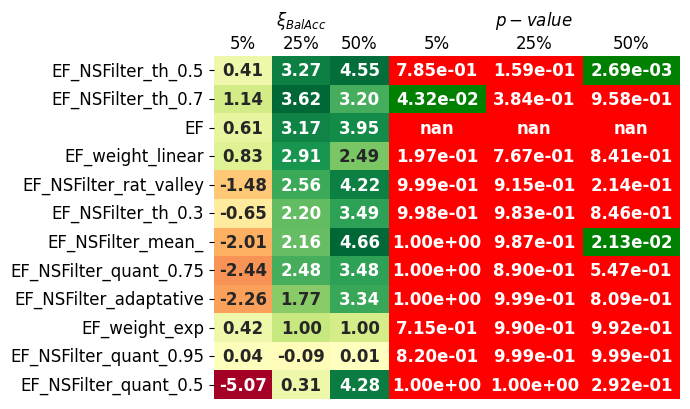

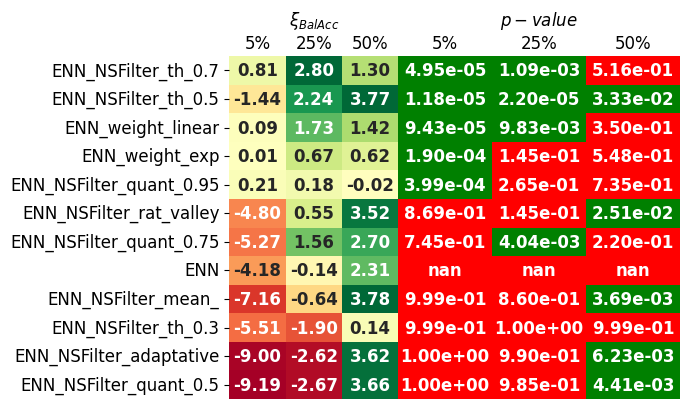

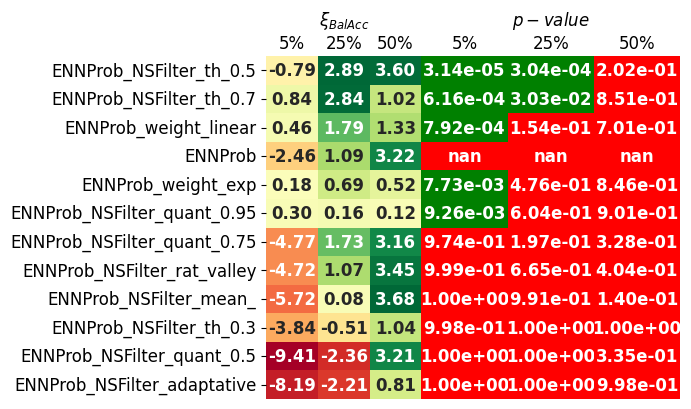

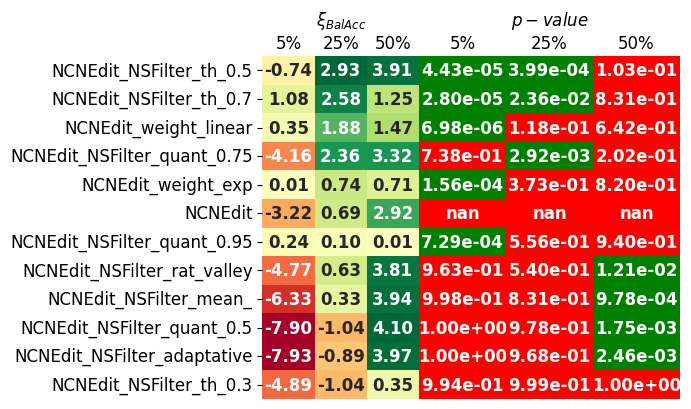

In [13]:
import seaborn as sns
noise_levels = [5, 25, 50]

for bf, tabla in tablas.items():
    diff = tabla["bal_acc_diff"].copy()
    pval = tabla["p_value"].copy()
    # pval = tabla["p_value_holm"].copy()

    fig, axes = plt.subplots(1, 6, figsize=(7, max(4, 0.35 * len(tabla))),
    gridspec_kw={"width_ratios": 3*[0.6]+[ 1, 1, 1], "wspace": 0.}
    )

    for i, nk in enumerate(noise_levels):
        sns.heatmap(
            diff[[nk]],
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            center=0,
            cbar=False,
            ax=axes[i],
            annot_kws={"size": 12, "weight":600},
        )
        if i==1:
            axes[i].set_title(r"$\xi_{BalAcc}$"+f"\n{nk}%")
        else:
            axes[i].set_title(f"{nk}%")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        axes[i].tick_params(axis="y", rotation=0, labelsize=12)
        axes[i].set_xticks([])
        if i!=0:
         axes[i].set_yticks([])

    for i, nk in enumerate(noise_levels):
        sig = (pval[[nk]] < 0.05).astype(int)
        sns.heatmap(
            sig,
            annot=pval[[nk]],
            fmt=".2e",
            cmap=sns.color_palette(["red", "green"], as_cmap=True),
            vmin=0,
            vmax=1,
            cbar=False,
            ax=axes[i + 3],
            annot_kws={"size": 12, "weight":600},
        )
        if i==1:
            axes[i+3].set_title(r"$p-value$"+f"\n{nk}%")
        else:
            axes[i+3].set_title(f"{nk}%")
        axes[i + 3].set_xlabel("")
        axes[i + 3].set_ylabel("")
        axes[i + 3].set_yticks([])
        axes[i+3].set_xticks([])

    plt.tight_layout()
    plt.savefig(base_path + f"/img/noiseScoringApproach/{bf}.png")
    plt.show()

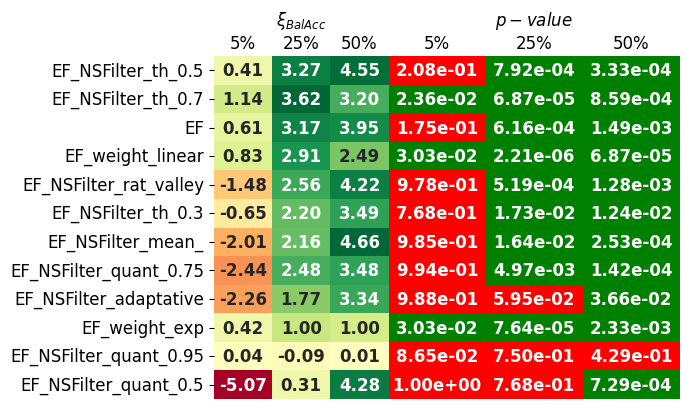

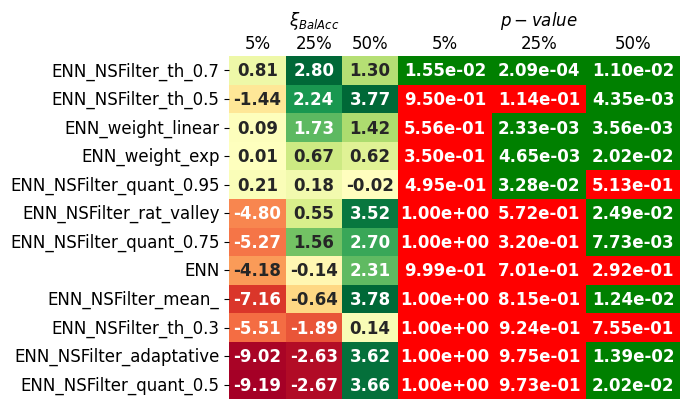

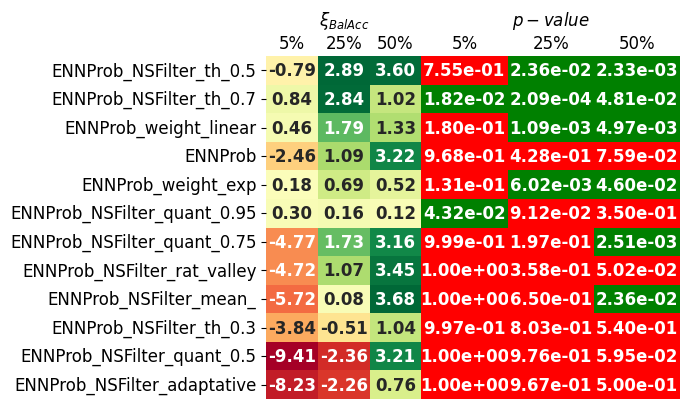

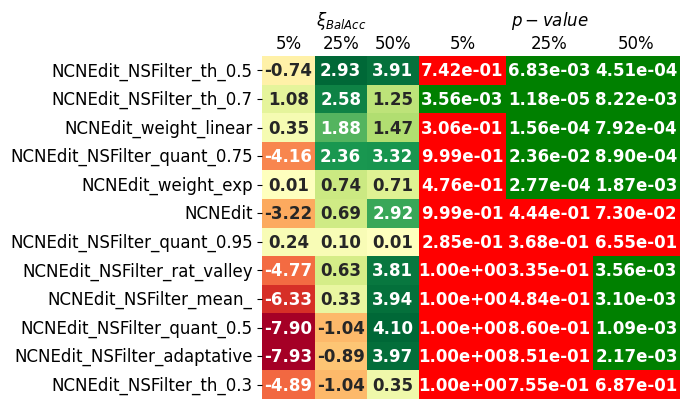

KeyError: 'p_value'

In [12]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

noise_levels = [5, 25, 50]

results = pickle.load(open("./results/nsBased.pkl", "rb"))
results = pd.DataFrame(results)

# Agrego por 5CV: media sobre folds
res = (
    results
    .groupby(["dataset_id", "seed", "filter_id", "noise_k"])
    .mean()
    .reset_index()
    .drop("fold_id", axis=1)
)

# Extraigo BalAcc sin filtro para cada dataset, seed y nivel de ruido
baseline_res = (
    res[res["filter_id"] == "None"]
    .drop(columns=["filter_id"])
    .rename(columns={"bal_acc": "baseline_bal_acc"})
)

# Añado el baseline a cada fila
res = res.merge(
    baseline_res,
    on=["dataset_id", "seed", "noise_k"],
    how="left",
)

# Diferencia respecto a no aplicar ningún filtro
res["bal_acc_diff"] = (res["bal_acc"] - res["baseline_bal_acc"]) * 100
res["base_filter"] = res["filter_id"].str.split("_").str[0]

# Agrego por semilla: media sobre seeds
res = (
    res
    .groupby(["dataset_id", "filter_id", "noise_k", "base_filter"])
    .mean()
    .reset_index()
    .drop("seed", axis=1)
)

# Agrego sobre datasets para obtener la mejora media
out = (
    res
    .drop("dataset_id", axis=1)
    .groupby(["filter_id", "noise_k", "base_filter"])
    .mean()
    .reset_index()
)

# Wilcoxon sobre bal_acc_diff: filtro vs no aplicar ningún filtro
tests = []

for (noise_k, filter_id), g in res[res["filter_id"] != "None"].groupby(["noise_k", "filter_id"]):
    diffs = g["bal_acc_diff"].dropna()

    if len(diffs) == 0:
        continue

    stat, p = wilcoxon(
        diffs,
        alternative="greater",
    )

    tests.append({
        "noise_k": noise_k,
        "filter_id": filter_id,
        "p_value": p,
        "wilcoxon_stat": stat,
        "n": len(diffs),
    })

tests_df = pd.DataFrame(tests)

out = out.merge(
    tests_df[["noise_k", "filter_id", "p_value", "wilcoxon_stat", "n"]],
    on=["noise_k", "filter_id"],
    how="left",
)

out["base_filter"] = out["filter_id"].str.split("_").str[0]

# Construyo una tabla por familia/base_filter
tablas = {}

for bf, g in out.groupby("base_filter"):
    orden = (
        g.groupby("filter_id")["bal_acc_diff"]
        .mean()
        .sort_values(ascending=False)
        .index
    )

    tabla = (
        g.pivot_table(
            index="filter_id",
            columns="noise_k",
            values=["bal_acc_diff", "p_value"],
        )
        .loc[orden]
    )

    tablas[bf] = tabla

# Visualización
for bf, tabla in tablas.items():
    diff = tabla["bal_acc_diff"].copy()
    pval = tabla["p_value"].copy()

    fig, axes = plt.subplots(
        1,
        6,
        figsize=(7, max(4, 0.35 * len(tabla))),
        gridspec_kw={
            "width_ratios": 3 * [0.6] + [1, 1, 1],
            "wspace": 0.0,
        },
    )

    for i, nk in enumerate(noise_levels):
        sns.heatmap(
            diff[[nk]],
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            center=0,
            cbar=False,
            ax=axes[i],
            annot_kws={"size": 12, "weight": 600},
        )

        if i == 1:
            axes[i].set_title(r"$\xi_{BalAcc}$" + f"\n{nk}%")
        else:
            axes[i].set_title(f"{nk}%")

        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        axes[i].tick_params(axis="y", rotation=0, labelsize=12)
        axes[i].set_xticks([])

        if i != 0:
            axes[i].set_yticks([])

    for i, nk in enumerate(noise_levels):
        sig = (pval[[nk]] < 0.05).astype(int)

        sns.heatmap(
            sig,
            annot=pval[[nk]],
            fmt=".2e",
            cmap=sns.color_palette(["red", "green"], as_cmap=True),
            vmin=0,
            vmax=1,
            cbar=False,
            ax=axes[i + 3],
            annot_kws={"size": 12, "weight": 600},
        )

        if i == 1:
            axes[i + 3].set_title(r"$p-value$" + f"\n{nk}%")
        else:
            axes[i + 3].set_title(f"{nk}%")

        axes[i + 3].set_xlabel("")
        axes[i + 3].set_ylabel("")
        axes[i + 3].set_yticks([])
        axes[i + 3].set_xticks([])

    plt.tight_layout()
    # plt.savefig(base_path + f"/img/noiseScoringApproach/{bf}_pvaluefr.png", dpi=300, bbox_inches="tight")
    plt.show()

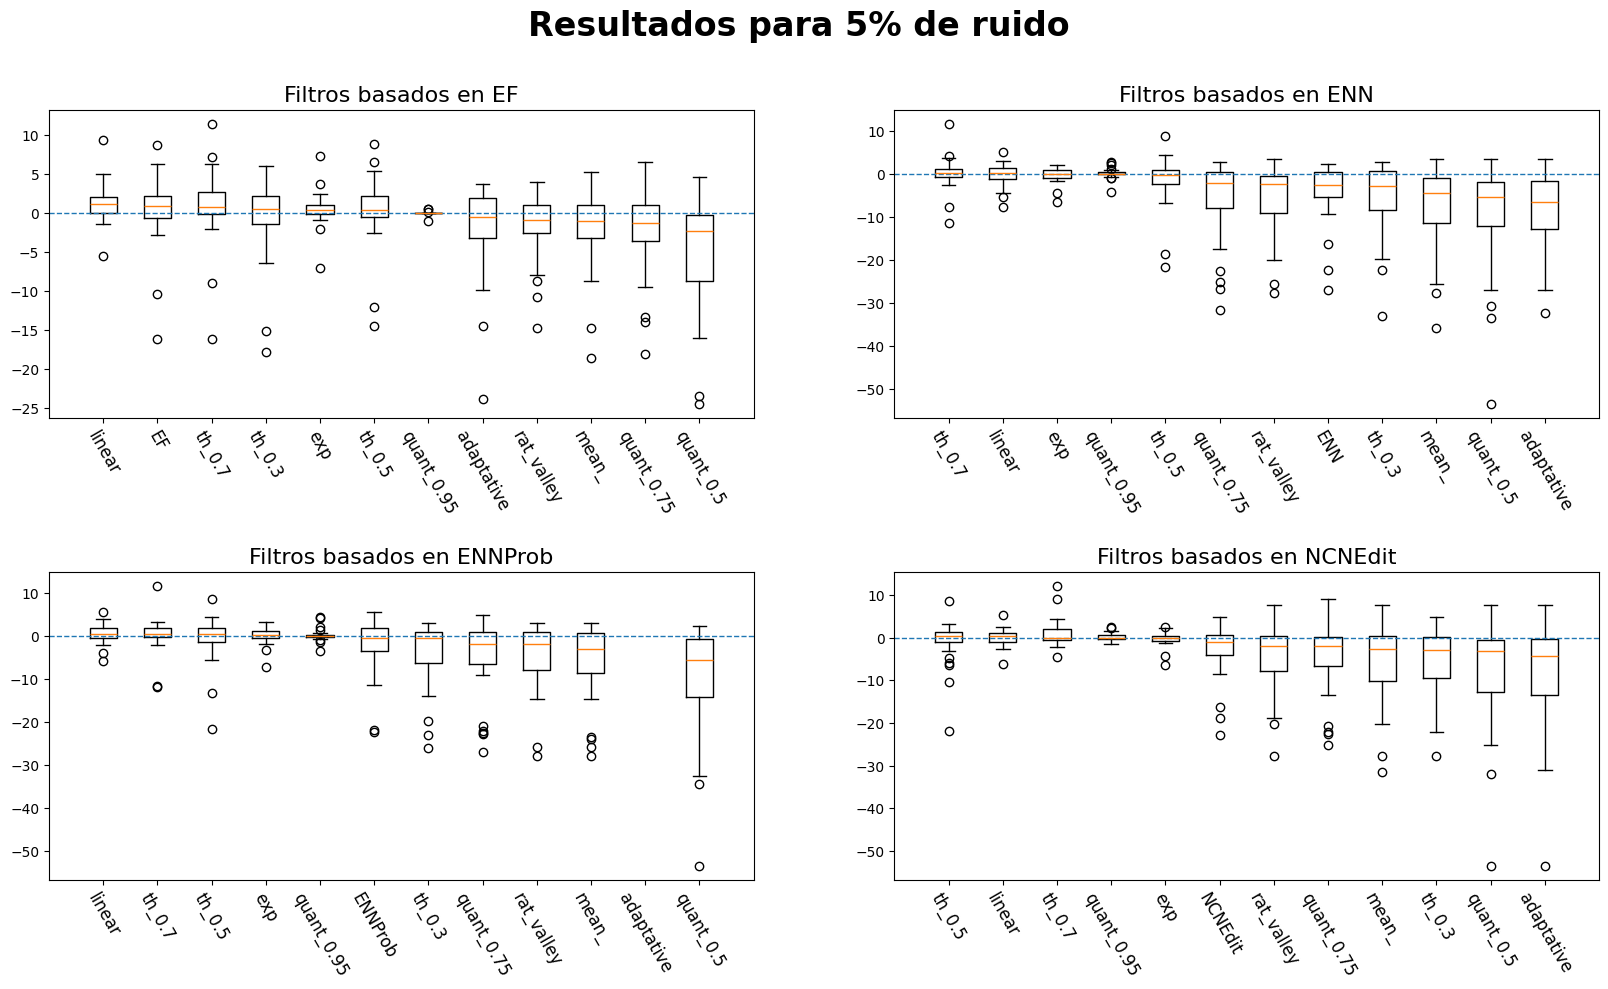

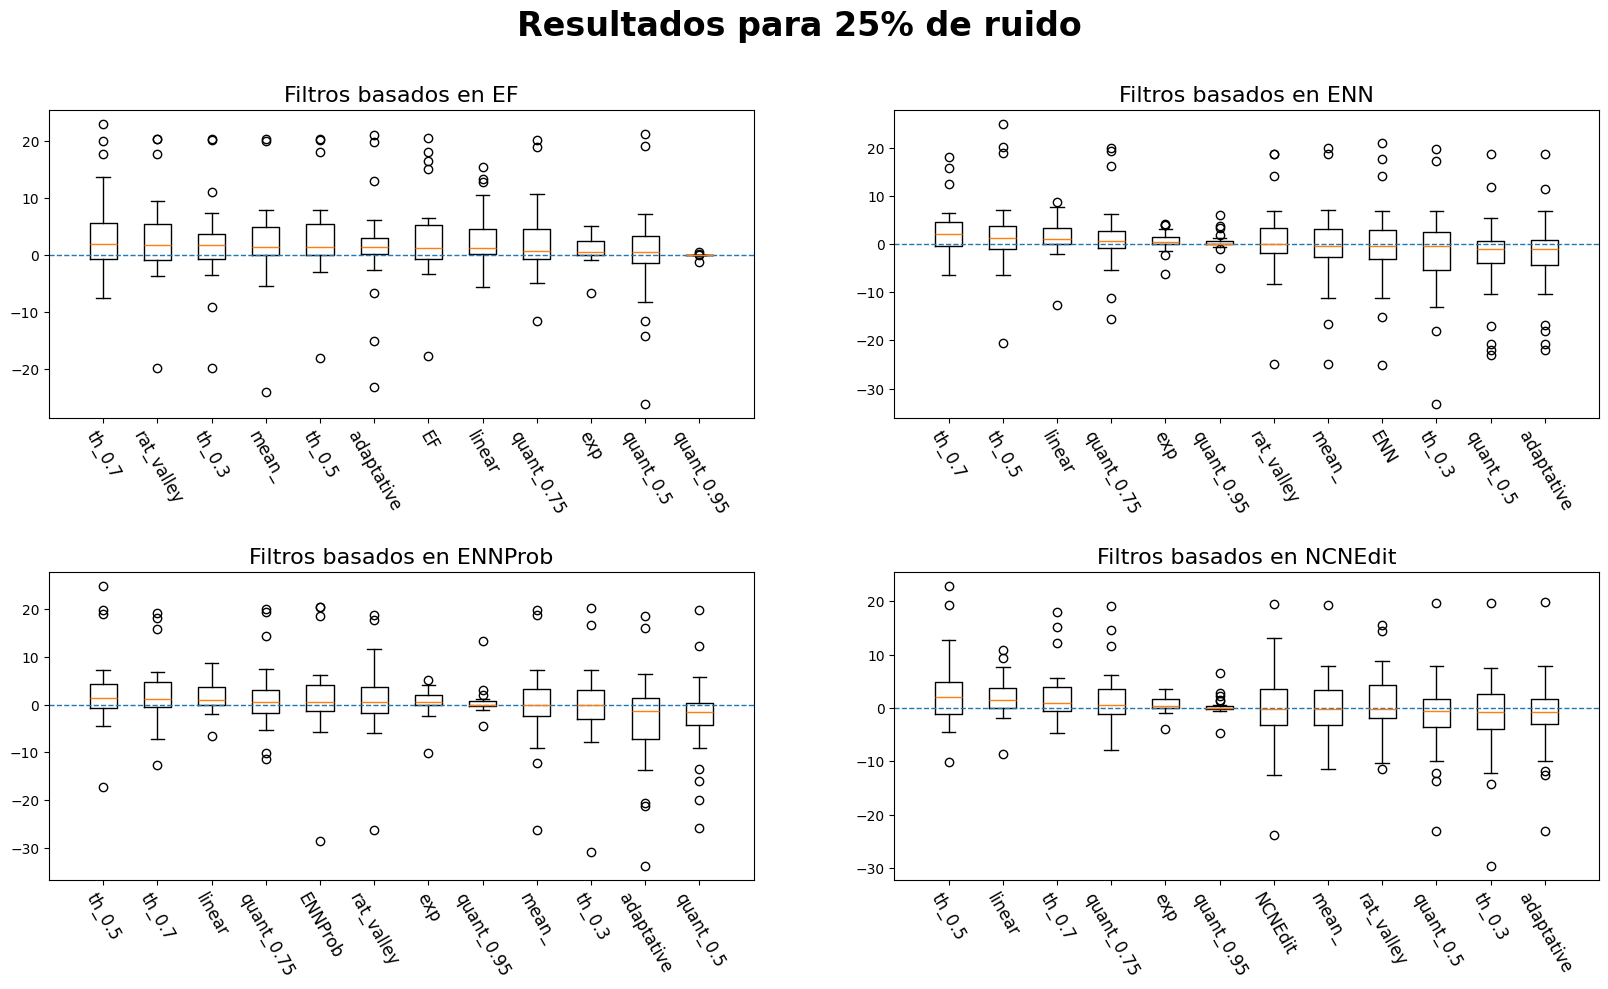

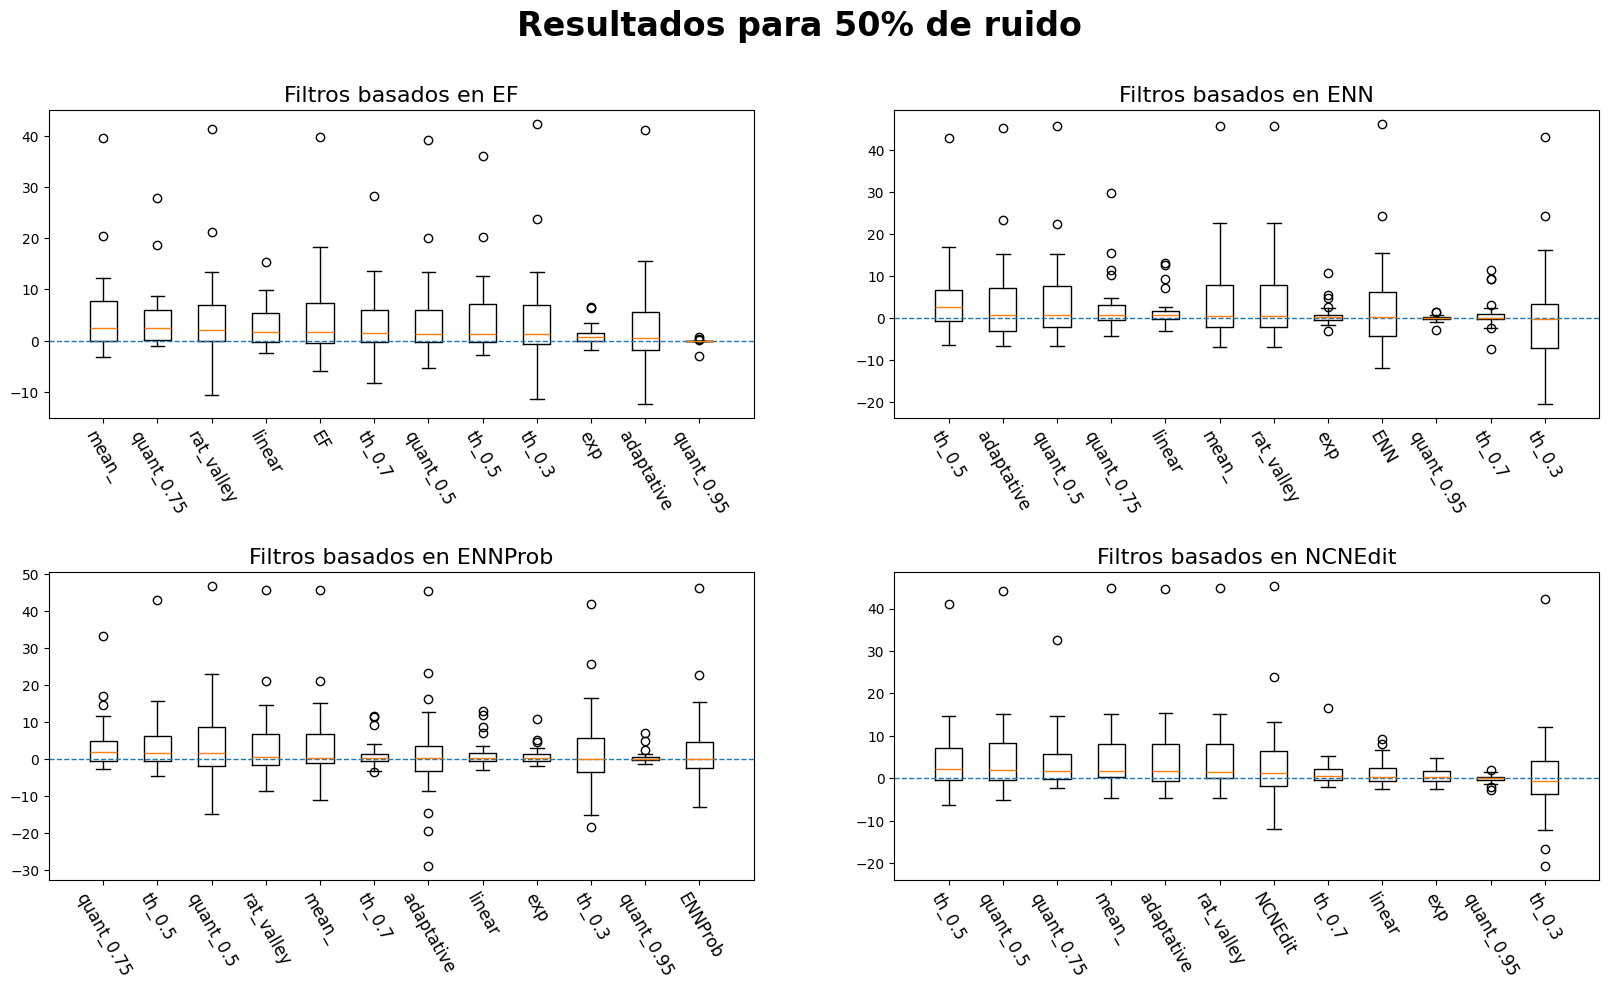

In [178]:
for noise_k in [5, 25, 50]:
    plt.figure(figsize=(20,10))
    for i, (bf, g) in enumerate(res[res.noise_k==noise_k].groupby("base_filter")):
        if bf!="None":
            plt.subplot(2,2,1+i)
            order = (
                g.groupby("filter_id")["bal_acc_diff"]
                .median()
                .sort_values(ascending=False)
                .index
            )

            data = [g.loc[g["filter_id"] == fid, "bal_acc_diff"] for fid in order]

            plt.boxplot(data)

            plt.title(f"Filtros basados en {bf}", fontsize=16)
            labels = [
                (fid if fid == bf else "_".join(fid.split("_")[2:]))
                for fid in order
            ]
            plt.xticks(np.arange(1, 1 + len(labels)), labels=labels, rotation=-60, fontsize=12)
            plt.hlines([0], xmin=0, xmax=len(labels) + 1, lw=1, ls="--")
            plt.xlim(0, len(labels) + 1)
            plt.subplots_adjust(hspace=0.5)
    plt.suptitle(f"Resultados para {noise_k}% de ruido", fontsize=24, fontweight=600)
    plt.savefig(base_path+f"/img/noiseScoringApproach/{noise_k}_boxplot.png")
    plt.show()